## Assignment - 1 CS626

### Imports

In [1]:
import nltk
from nltk.corpus import brown
import pandas as pd
import numpy as np
import matplotlib.pylab as pl
import seaborn as sns

In [2]:
nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


True

### Pre-processing

In [3]:
# get statements 
statements_tags = brown.tagged_sents(tagset="universal")

In [4]:
print(len(statements_tags))
print(statements_tags[0])

57340
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


In [5]:
data = []
for s in range(len(statements_tags)):
  g = []
  for word_tag in range(len(statements_tags[s])):
    g.append([statements_tags[s][word_tag][0].lower(), statements_tags[s][word_tag][1]])
  data.append(g)

print(data[0])

[['the', 'DET'], ['fulton', 'NOUN'], ['county', 'NOUN'], ['grand', 'ADJ'], ['jury', 'NOUN'], ['said', 'VERB'], ['friday', 'NOUN'], ['an', 'DET'], ['investigation', 'NOUN'], ['of', 'ADP'], ["atlanta's", 'NOUN'], ['recent', 'ADJ'], ['primary', 'NOUN'], ['election', 'NOUN'], ['produced', 'VERB'], ['``', '.'], ['no', 'DET'], ['evidence', 'NOUN'], ["''", '.'], ['that', 'ADP'], ['any', 'DET'], ['irregularities', 'NOUN'], ['took', 'VERB'], ['place', 'NOUN'], ['.', '.']]


In [6]:
# print tagset
tagged_words=[tup for sent in data for tup in sent]
tags=set([tag for word,tag in tagged_words])
print(tags)

{'X', 'ADP', 'VERB', 'DET', 'NOUN', 'PRT', 'PRON', 'CONJ', 'ADV', 'ADJ', '.', 'NUM'}


### Split Train and Test Data

In [7]:
frac = 0.8 
np.random.seed(0)
train_sz = int(frac * len(data))
indices_train = np.ones((train_sz,), dtype = int)
indices_train = np.append(indices_train, np.zeros((len(data)-train_sz,), dtype = int))
np.random.shuffle(indices_train)

In [8]:
train_data = []
test_data = []
for ind in range(len(indices_train)):
  if indices_train[ind] == 1:
    train_data.append(data[ind])
  else:
    test_data.append(data[ind])

In [9]:
print(len(train_data), len(test_data))
print(train_data[1])
print(train_data[0])

words_0_train = set([w[0] for w in train_data[0]])
print(len(words_0_train))

45872 11468
[['the', 'DET'], ['jury', 'NOUN'], ['further', 'ADV'], ['said', 'VERB'], ['in', 'ADP'], ['term-end', 'NOUN'], ['presentments', 'NOUN'], ['that', 'ADP'], ['the', 'DET'], ['city', 'NOUN'], ['executive', 'ADJ'], ['committee', 'NOUN'], [',', '.'], ['which', 'DET'], ['had', 'VERB'], ['over-all', 'ADJ'], ['charge', 'NOUN'], ['of', 'ADP'], ['the', 'DET'], ['election', 'NOUN'], [',', '.'], ['``', '.'], ['deserves', 'VERB'], ['the', 'DET'], ['praise', 'NOUN'], ['and', 'CONJ'], ['thanks', 'NOUN'], ['of', 'ADP'], ['the', 'DET'], ['city', 'NOUN'], ['of', 'ADP'], ['atlanta', 'NOUN'], ["''", '.'], ['for', 'ADP'], ['the', 'DET'], ['manner', 'NOUN'], ['in', 'ADP'], ['which', 'DET'], ['the', 'DET'], ['election', 'NOUN'], ['was', 'VERB'], ['conducted', 'VERB'], ['.', '.']]
[['the', 'DET'], ['fulton', 'NOUN'], ['county', 'NOUN'], ['grand', 'ADJ'], ['jury', 'NOUN'], ['said', 'VERB'], ['friday', 'NOUN'], ['an', 'DET'], ['investigation', 'NOUN'], ['of', 'ADP'], ["atlanta's", 'NOUN'], ['recent', 

### Finding no. of unknown words

In [10]:
tagged_words_train = [tup for sent in train_data for tup in sent]
words_train=set([word[0] for word in tagged_words_train])
print("No. of distinct words in train data: ",len(words_train))   #no. of distinct words in train data

tagged_words_test=[tup for sent in test_data for tup in sent]
words_test=set([word for word,tag in tagged_words_test])
print("No. of distinct words in test data: ",len(words_test))  #no. of distinct words in test data

count=0
for word in words_test:
  if word not in words_train:
    count+=1
print("No. of distinct unknown words in test data: ",count)   #no. of unknown words in test data
 

No. of distinct words in train data:  45105
No. of distinct words in test data:  22833
No. of distinct unknown words in test data:  4710


### Emission Probability

In [11]:
### emission probability
word_tag_pairs = []
for t in train_data:
  for j in t:
    word_tag_pairs.append(j)
pairs_df = pd.DataFrame(word_tag_pairs, columns = ["word", "tag"])
print(pairs_df)

              word   tag
0              the   DET
1           fulton  NOUN
2           county  NOUN
3            grand   ADJ
4             jury  NOUN
...            ...   ...
931074      boucle  NOUN
931075       dress  NOUN
931076         was  VERB
931077  stupefying  VERB
931078           .     .

[931079 rows x 2 columns]


In [12]:
count_pairs_df = pairs_df.groupby(pairs_df.columns.tolist(),as_index=False).size()
print(count_pairs_df)

              word   tag  size
0                !     .  1286
1            $.027  NOUN     2
2             $.03  NOUN     2
3        $.054/mbf  NOUN     1
4             $.07  NOUN     2
...            ...   ...   ...
48458  zubkovskaya  NOUN     1
48459      zurcher  NOUN     1
48460       zurich  NOUN     1
48461     zworykin  NOUN     1
48462        {0,t}  NOUN     1

[48463 rows x 3 columns]


In [13]:
tags_df = pairs_df.groupby(['tag'],as_index=False).size()
tags_df = tags_df.set_index("tag")
print(tags_df.head(12))

        size
tag         
.     118147
ADJ    67047
ADP   116218
ADV    45032
CONJ   30594
DET   109773
NOUN  220690
NUM    11965
PRON   39774
PRT    23926
VERB  146771
X       1142


In [14]:
em_prob = {}
for index, row in count_pairs_df.iterrows():
  prob = row["size"]/(tags_df.loc[row["tag"]]["size"])
  em_prob[row["word"], row["tag"]] = prob
  if index % 10000 == 0:
    print(index)


0
10000
20000
30000
40000


In [15]:
e = {}
for x in em_prob:
  for state in tags:
    if (x[0], state) not in em_prob:
      e[x[0], state] = 0
    else:
      e[x[0], state] = em_prob[x[0], state]

In [16]:
print(len(e), len(count_pairs_df))   #len(e) is no. of tag * no. of words in dataframe
# print(e['the', 'PRT'])

541260 48463


### Transition Probability

In [17]:
tag_tag_pairs = []
for t in train_data:
  for p in range(len(t)-1):
    tag_tag_pairs.append([t[p][1], t[p+1][1]])
tag_tag_df = pd.DataFrame(tag_tag_pairs, columns = ["tag", "next_tag"])
# print(tag_tag_df)

In [18]:
count_tags_df = tag_tag_df.groupby(tag_tag_df.columns.tolist(),as_index=False).size()

In [19]:
print(count_tags_df.head(15))

    tag next_tag   size
0     .        .  12649
1     .      ADJ   3383
2     .      ADP   7683
3     .      ADV   5123
4     .     CONJ   8236
5     .      DET   7932
6     .     NOUN   9839
7     .      NUM   1420
8     .     PRON   5565
9     .      PRT   2158
10    .     VERB   9053
11    .        X    161
12  ADJ        .   6717
13  ADJ      ADJ   3839
14  ADJ      ADP   5885


In [20]:
total_tags_df = tag_tag_df.groupby(["tag"],as_index=False).size()
total_tags_df = total_tags_df.set_index("tag")

In [21]:
trans_prob = {}
for index, row in count_tags_df.iterrows():
  
  prob = row["size"]/(total_tags_df.loc[row["tag"]]["size"])
  trans_prob[row["tag"], row["next_tag"]] = prob
  if index % 1000 == 0:
    print(index)


0


In [22]:
ti = {}
for x in trans_prob:
  for state in tags:
    if (x[0], state) not in trans_prob:
      ti[x[0], state] = 0
    else:
      ti[x[0], state] = trans_prob[x[0], state] 

In [23]:
print(ti['ADP', 'X'])

0.0004646680205142326


In [24]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
indices_map = {'NOUN': 0,'VERB':1, 'PRON' : 2, 'ADJ' : 3, 'ADV': 4, 'ADP' : 5, 'CONJ': 6, 'DET': 7, 'NUM': 8, 'PRT' :9, 'X':10, '.':11}

In [25]:
nx = 12
ny = 12
transition_matrix = np.zeros((nx,ny))

for tag_data in ti:
    # print(tag_data)
    transition_matrix[indices_map[tag_data[0]]][indices_map[tag_data[1]]] = ti[tag_data]

transition_matrix = np.array([row for row in transition_matrix])
transition_matrix = np.around(transition_matrix, decimals = 4)

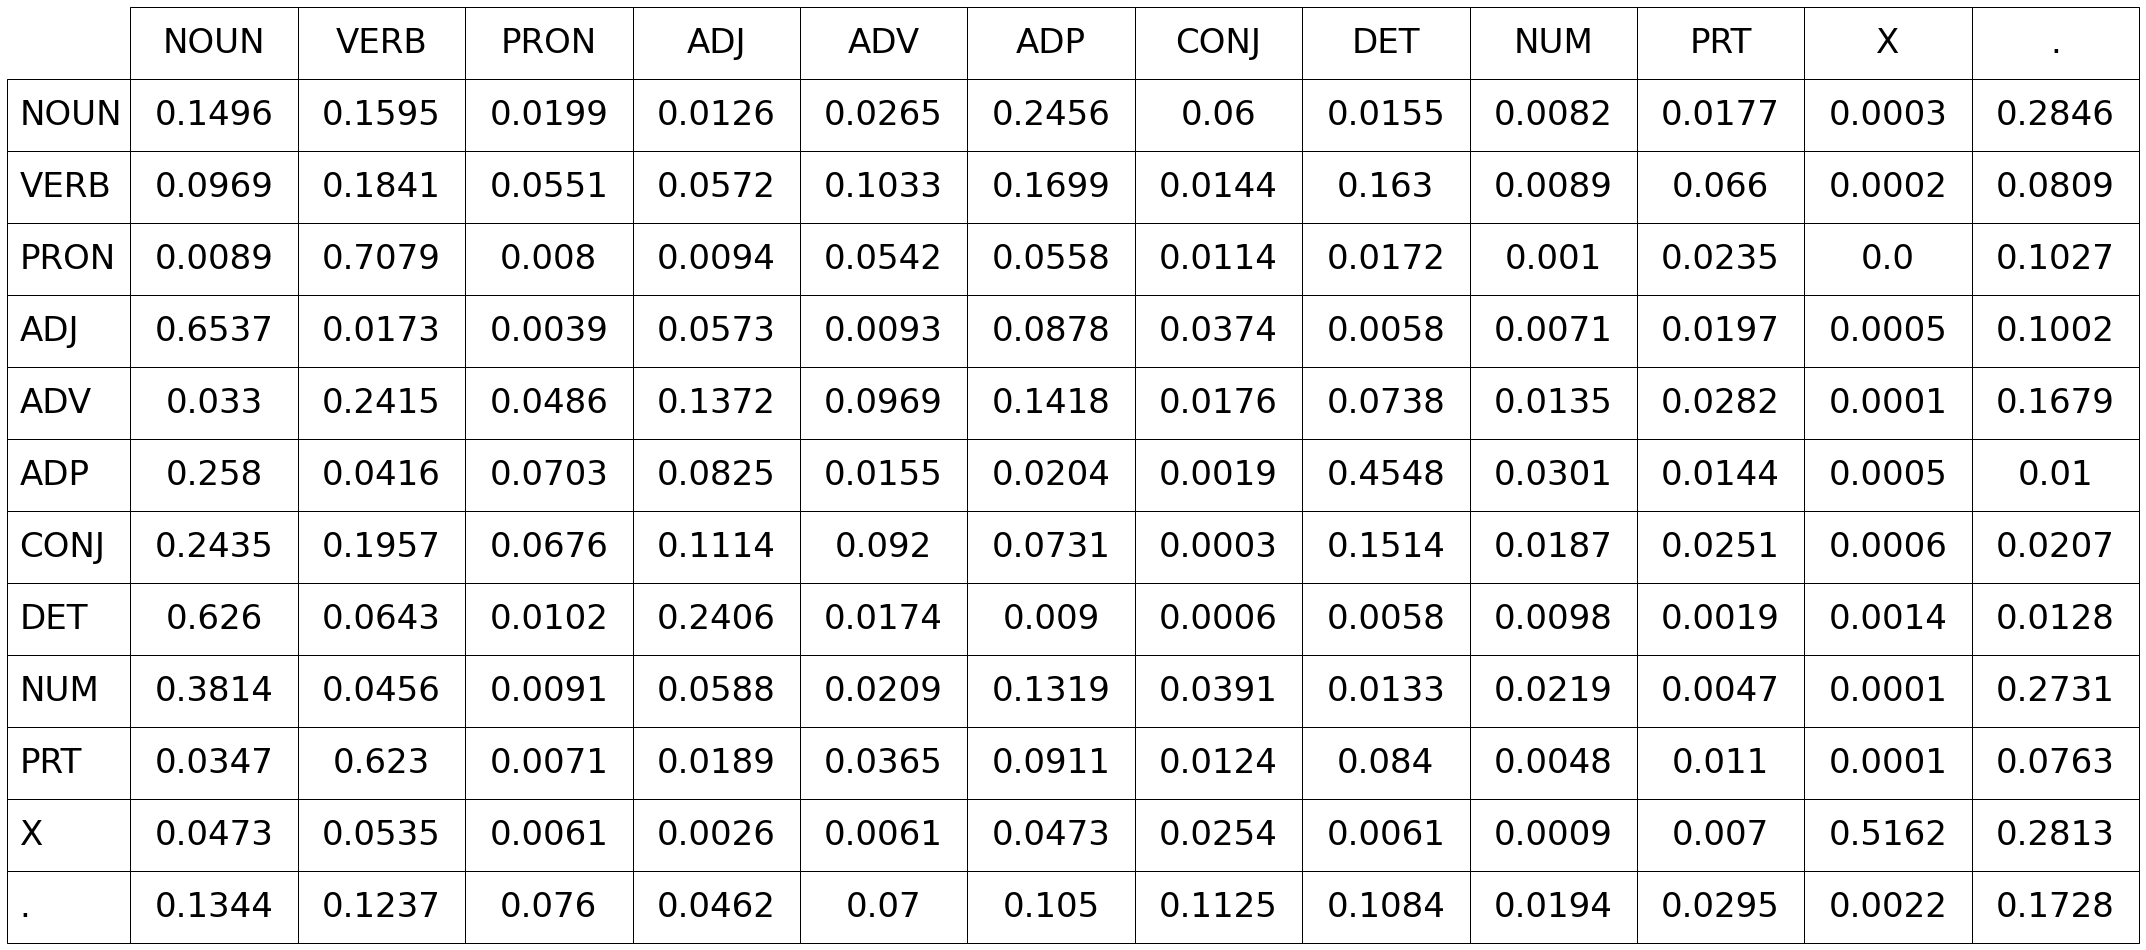

In [26]:
pl.figure()
tb = pl.table(cellText=transition_matrix, loc=(0,0), cellLoc='center', colLabels = tags, rowLabels = tags)

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)



### Start Probability

In [27]:
start_tags = []
for t in train_data:
  start_tags.append(t[0])
start_prob_df = pd.DataFrame(start_tags, columns = ["word", "tag"])
start_prob_df = start_prob_df.groupby(["tag"],as_index=False).size()
start_prob_df = start_prob_df.set_index("tag")

In [28]:
sum_start_tags = start_prob_df["size"].sum() # 45872

In [29]:
start_prob_df["size"] = start_prob_df["size"].divide(sum_start_tags)

In [30]:
start_prob = {}
for index, row in start_prob_df.iterrows():
  start_prob[index] = row["size"]
print(start_prob)

{'.': 0.08879054761074294, 'ADJ': 0.03374607603767004, 'ADP': 0.1240408092082316, 'ADV': 0.08977153819323334, 'CONJ': 0.04841733519358214, 'DET': 0.21422654342518313, 'NOUN': 0.14211283571677713, 'NUM': 0.01711283571677712, 'PRON': 0.16009766306243461, 'PRT': 0.036580048831531216, 'VERB': 0.044602371817230556, 'X': 0.0005013951866062085}


### Viterbi Algorithm

In [58]:
def viterbi(input_sent, trans_prob, em_prob, start_prob, tags):
  
  path_prob = {} # for probability computation
  path_pointer = {} # for pos tags of best path

  # start probability for first word in sentence
  if (input_sent[0], 'NOUN') not in em_prob:
    for s in tags:
        path_prob[s, 0] = 0
        path_pointer[s, 0] = [s]
    path_prob[s,'X'] = 1
  else:
    for s in tags:
        path_prob[s, 0] = start_prob[s] * em_prob[input_sent[0], s]
        path_pointer[s, 0] = [s]
  
  # for words in sentence
  for o in range(1, len(input_sent)):
      obs = input_sent[o]
      for s in tags:
        # calculate path probability of each state for given word
        if (obs, s) not in em_prob:
          flag = 0
          if s == 'X':
            flag = 1
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * flag, k) for k in tags]
          k = sorted(v1)[-1][1] # find maximum probability path
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * flag
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
        else:
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s], k) for k in tags]
          k = sorted(v1)[-1][1]
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s]
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
  
  #find max prob path
  last_k = sorted([(path_prob[k, len(input_sent)-1], k) for k in tags])[-1][1]
  pointers = path_pointer[last_k, len(input_sent)-1] # path for max prob
  best_path = [[input_sent[o], pointers[o]] for o in range(len(pointers))]
  return best_path

### Approach 2

In [59]:
def viterbi_2(input_sent, trans_prob, em_prob, start_prob, tags):
  
  path_prob = {} # for probability computation
  path_pointer = {} # for pos tags of best path

  # start probability for first word in sentence
  if (input_sent[0], 'NOUN') not in em_prob:
    for s in tags:
        path_prob[s, 0] = 1
        path_pointer[s, 0] = [s]
  else:
    for s in tags:
        path_prob[s, 0] = start_prob[s] * em_prob[input_sent[0], s]
        path_pointer[s, 0] = [s]
  
  # for words in sentence
  for o in range(1, len(input_sent)):
      obs = input_sent[o]
      for s in tags:
        # calculate path probability of each state for given word
        if (obs, s) not in em_prob:
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * 1, k) for k in tags]
          k = sorted(v1)[-1][1] # find maximum probability path
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * 1
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
        else:
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s], k) for k in tags]
          k = sorted(v1)[-1][1]
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s]
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
  
  #find max prob path
  last_k = sorted([(path_prob[k, len(input_sent)-1], k) for k in tags])[-1][1]
  pointers = path_pointer[last_k, len(input_sent)-1] # path for max prob
  best_path = [[input_sent[o], pointers[o]] for o in range(len(pointers))]
  return best_path

### Inference

In [60]:
def test(test_str, trans_prob, em_prob, start_prob, tags):
  test_list = test_str.lower().split()
  return viterbi(test_list, trans_prob, em_prob, start_prob, tags)
  

In [61]:
test_str = "If the river was channelized properly , the wheat cultivation would not have suffered due to water scarcity ."
trans_prob_test = ti
em_prob_test = e
start_prob_test = start_prob
tags_test = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
print(test_str)
print(test(test_str, trans_prob_test, em_prob_test, start_prob_test, tags_test))

If the river was channelized properly , the wheat cultivation would not have suffered due to water scarcity .
[['if', 'ADP'], ['the', 'DET'], ['river', 'NOUN'], ['was', 'VERB'], ['channelized', 'X'], ['properly', 'ADV'], [',', '.'], ['the', 'DET'], ['wheat', 'NOUN'], ['cultivation', 'NOUN'], ['would', 'VERB'], ['not', 'ADV'], ['have', 'VERB'], ['suffered', 'VERB'], ['due', 'ADJ'], ['to', 'ADP'], ['water', 'NOUN'], ['scarcity', 'NOUN'], ['.', '.']]


In [34]:
test_results = []
for t_data in test_data:
  try:
    sentence = [j[0] for j in t_data]
    pred = viterbi(sentence, ti, e, start_prob, tags)
    test_results.append([t_data, pred])
  except:
    continue

In [35]:
print(len(test_data), len(test_results)) #11468 11468
#print(test_data[0])
print([j[0] for j in test_data[4]])
print(test_results[4][0]) #test_data
print(test_results[4][1]) #pred_data


11468 11468
['wards', 'protected']
[['wards', 'NOUN'], ['protected', 'VERB']]
[['wards', 'NOUN'], ['protected', 'VERB']]


### Examples of sentences with actual tag and predicted tag

In [36]:
def tags(index):
  labels = [j[0] for j in test_results[index][0]]
  test_data_tag = [j[1] for j in test_results[index][0]]
  pred_data_tag = [j[1] for j in test_results[index][1]]
  data_tag = [test_data_tag,pred_data_tag]
  return [labels,data_tag]

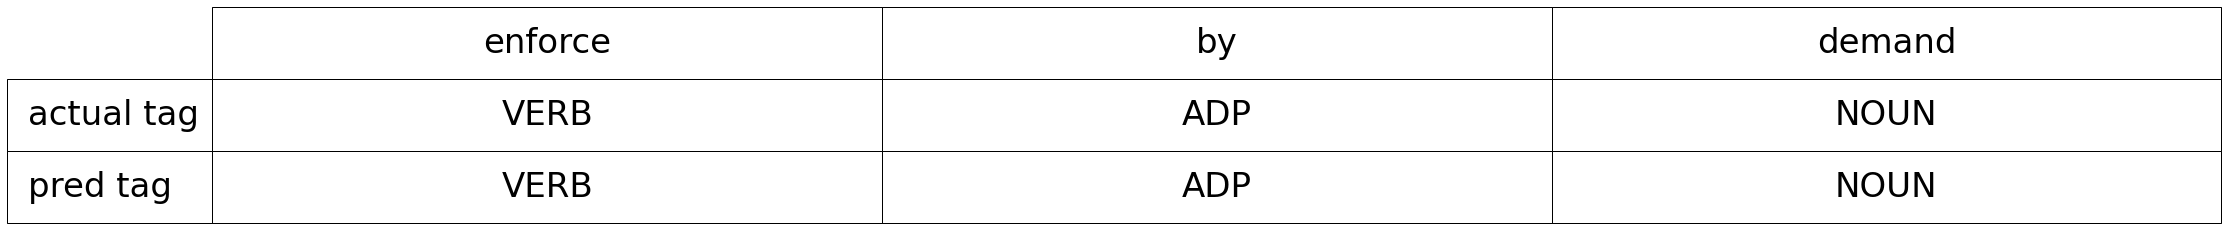

In [37]:
row_labels = ['actual tag','pred tag']
[labels,data_tag] = tags(80)
pl.figure()
tb = pl.table(cellText=data_tag, loc=(0,0), colLabels = labels, rowLabels = row_labels, cellLoc='center')
tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)

### Classify Data w.r.t Each Tag

In [38]:
def classify(test_results,tag):
       cpred_data=[]
       ctest_data=[]
       for t_data in test_results:
         for j in t_data[0]:
              if j[1]==tag:
                    cpred_data.append([j[0],j[1],1])
              else:
                    cpred_data.append([j[0],j[1],0])
         for j in t_data[1]:
              if j[1]==tag:
                    ctest_data.append([j[0],j[1],1])
              else:
                    ctest_data.append([j[0],j[1],0])
       class_results = []
       class_results.append([cpred_data,ctest_data])
       return class_results 

In [39]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']

In [40]:
classify_data = []
for tag in tags:
    classify_data.append([tag,classify(test_results,tag)])

# print(classify_data[11][1][0][1]) #pred_data_classify
#print(len(classify_data[11][1][0]))

### Calculations of TP, FP, TN, FN for each tag

In [41]:
def measure(tag,results):
    TP = 0
    FP = 0
    TN = 0
    FN = 0
    for i in range(len(results[0])): 
        if results[1][i][2]==results[0][i][2]==1:
           TP += 1
        if results[0][i][2]==1 and results[1][i][2]!=results[0][i][2]:
           FP += 1
        if results[1][i][2]==results[0][i][2]==0:
           TN += 1
        if results[0][i][2]==0 and results[1][i][2]!=results[0][i][2]:
           FN += 1
    return[tag,TP, FP, TN, FN]

In [42]:
count = []
i=0
for result in classify_data:
        count.append(measure(tags[i],result[1][0]))
        i+=1
#print(count)
table = pd.DataFrame(count, columns = ["tag","TP", "FP","TN","FN"])
print(table)

     tag     TP    FP      TN    FN
0   NOUN  50125  4743  173785  1460
1   VERB  33706  2273  193441   693
2   PRON   9331   229  220298   255
3    ADJ  14703  1971  212422  1017
4    ADV   9926  1281  217867  1039
5    ADP  27410  1138  200509  1056
6   CONJ   7370   187  222507    49
7    DET  26626   620  202713   154
8    NUM   2664   245  227127    77
9    PRT   5244   659  223687   523
10     X    215    29  222481  7388
11     .  29075   343  200688     7


### Precision, Recall, F1 Score for each tag

In [43]:
def metrics(tag,TP,FN,FP):
  precision = TP/(TP+FP)
  recall = TP/(TP+FN)
  F1 = 2 * precision * recall/(recall + precision)
  F2 = 5 * precision * recall/(recall + (4 * precision))
  F05 = 1.25 * precision * recall/(recall + (0.25 * precision))
  return[tag,TP,FN,FP,precision,recall,F1,F2,F05]

In [44]:
metric = []
i=0
for data in count:
  TP = data[1]
  FN = data[4]
  FP = data[2]
  metric.append(metrics(tags[i],TP,FN,FP))
  i+=1
print(metric)
metrics_table = pd.DataFrame(metric, columns = ["tag","TP","FN","FP","precision", "recall","F1-score","F2-score","F0.5-score"])
print(metrics_table)

[['NOUN', 50125, 1460, 4743, 0.9135561711744551, 0.9716971987981002, 0.9417301532131551, 0.9594843955774707, 0.924621020670929], ['VERB', 33706, 693, 2273, 0.9368242585952917, 0.9798540655251606, 0.9578561482281396, 0.9709347544289212, 0.945125199786894], ['PRON', 9331, 255, 229, 0.9760460251046025, 0.9733987064469017, 0.9747205682649117, 0.9739270207080829, 0.9755154100280182], ['ADJ', 14703, 1017, 1971, 0.8817920115149335, 0.9353053435114503, 0.9077606964252639, 0.9240892978354326, 0.8919991263832266], ['ADV', 9926, 1039, 1281, 0.8856964397251718, 0.9052439580483356, 0.8953635215587227, 0.9012657308369804, 0.8895381141003351], ['ADP', 27410, 1056, 1138, 0.960137312596329, 0.9629031124850699, 0.9615182235942049, 0.9623486784821506, 0.9606892007458397], ['CONJ', 7370, 49, 187, 0.975254730713246, 0.9933953362986926, 0.984241452991453, 0.9897134262616496, 0.9788296544213351], ['DET', 26626, 154, 620, 0.9772443661454893, 0.9942494398805078, 0.985673564580017, 0.9908012443624132, 0.9805986

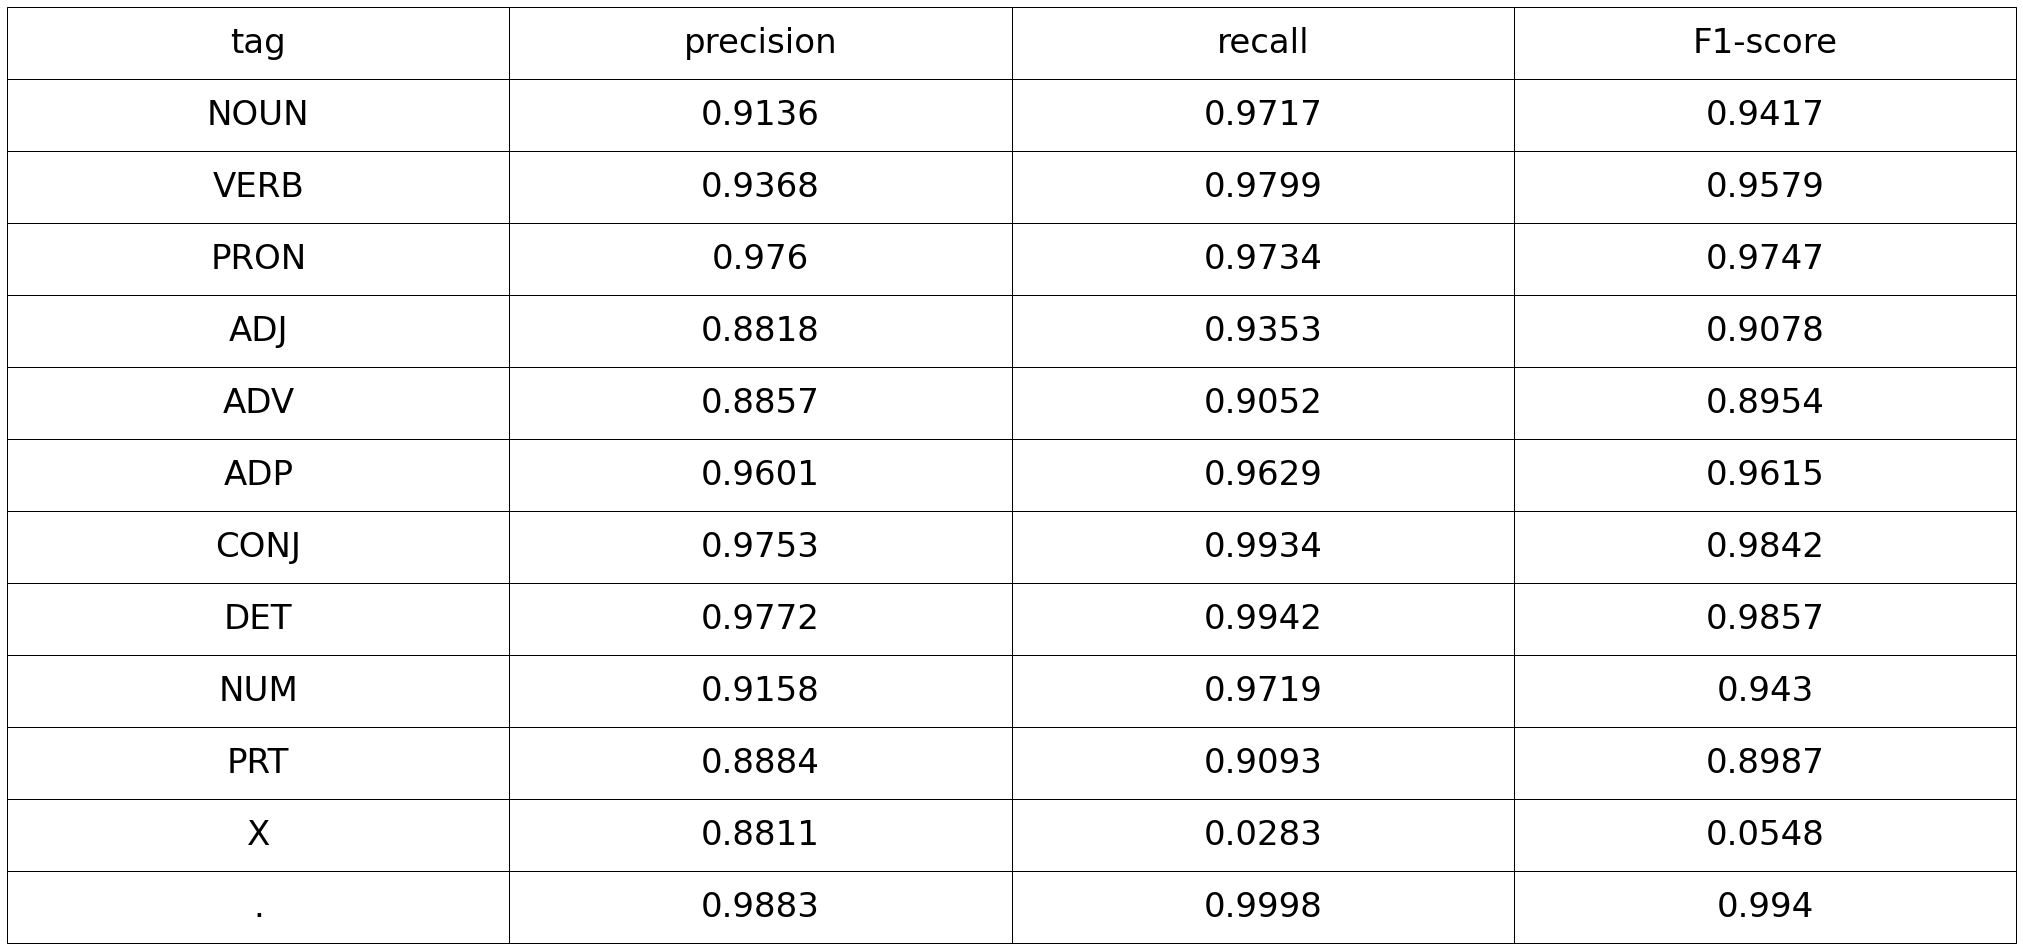

In [45]:
labels = ["tag","precision", "recall","F1-score"]
pl.figure()

metric_show = metric
met = []
mp = 0
mr = 0
mf = 0
for m in metric_show:
  mp = round(m[4], 4)
  mr = round(m[5], 4)
  mf = round(m[6], 4)
  met.append([m[0],mp,mr,mf])


# metric_np = np.around(metric_np, decimals = 4)
tb = pl.table(cellText=met, loc=(0,0), colLabels = labels, cellLoc='center')

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)

### Overall Performance in terms of precision, recall, F1 score, F2 score, F0.5 score

### Weighted Averages

In [46]:
prec_add=0
reca_add=0
F1_add=0
F2_add=0
F05_add=0
total=0
for metric_each in metric:
  prec_add += metric_each[4]*(metric_each[1]+metric_each[2])
  reca_add += metric_each[5]*(metric_each[1]+metric_each[2])
  F1_add += metric_each[6]*(metric_each[1]+metric_each[2])
  F2_add += metric_each[7]*(metric_each[1]+metric_each[2])
  F05_add += metric_each[8]*(metric_each[1]+metric_each[2])
  total += metric_each[1]+metric_each[2]

precision = prec_add/total
recall = reca_add/total
F1 = F1_add/total
F2 = F2_add/total
F05 = F05_add/total
print("precision: ",precision)
print("recall: ",recall)
print("F1: ",F1)
print("F2: ",F2)
print("F0.5: ",F05)

precision:  0.939079164974401
recall:  0.9403858104496486
F1:  0.9261583932721396
F2:  0.9344781780283218
F0.5:  0.919775916281351


### Accumulated Performance

In [47]:
TP=0
FN=0
FP=0
for data in count:
      TP += data[1]
      FN += data[4]
      FP += data[2]
precision = TP/(TP+FP)
recall = TP/(TP+FN)
F1 = 2 * precision * recall/(recall + precision)
F2 = 5 * precision * recall/(recall + (4 * precision))
F05 = 1.25 * precision * recall/(recall + (0.25 * precision))
print("precision: ",precision)
print("recall: ",recall)
print("F1: ",F1)
print("F2: ",F2)
print("F0.5: ",F05)

precision:  0.9403858104496486
recall:  0.9403858104496486
F1:  0.9403858104496486
F2:  0.9403858104496488
F0.5:  0.9403858104496488


### Confusion matrix

In [48]:
def build_confusion(test_results, tags):
  confusion_mat = {}
  for tag in tags:
    for t_data in test_results:
      for j in range(len(t_data[1])):
        if tag == t_data[0][j][1]:
          if (tag, t_data[1][j][1]) not in confusion_mat:
            confusion_mat[tag, t_data[1][j][1]] = 1
          else:
            confusion_mat[tag, t_data[1][j][1]] += 1
  return confusion_mat

In [49]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
indices_map = {'NOUN': 0,'VERB':1, 'PRON' : 2, 'ADJ' : 3, 'ADV': 4, 'ADP' : 5, 'CONJ': 6, 'DET': 7, 'NUM': 8, 'PRT' :9, 'X':10, '.':11}
confusion_matrix = build_confusion(test_results,tags)

In [50]:
# print(confusion_matrix)

In [51]:
# for tag in confusion_matrix:
#   print("Tag: ", tag, confusion_matrix[tag])
  # for vals in tag[0]:
  #   print(vals, tag[0][vals])

In [62]:
nx = 12
ny = 12
data_confusion = np.zeros((nx,ny))

for tag_data in confusion_matrix:
    data_confusion[indices_map[tag_data[0]]][indices_map[tag_data[1]]] = confusion_matrix[tag_data]

data_confusion = np.array([1.0*row/row.sum() for row in data_confusion])
# data_confusion = np.array([row for row in data_confusion])
data_confusion = np.around(data_confusion, decimals = 4)

In [63]:
print(data_confusion)

[[9.136e-01 1.090e-02 0.000e+00 8.500e-03 6.000e-04 0.000e+00 0.000e+00
  2.000e-04 1.300e-03 2.000e-04 6.460e-02 0.000e+00]
 [2.900e-02 9.368e-01 0.000e+00 2.400e-03 3.000e-04 9.000e-04 0.000e+00
  0.000e+00 0.000e+00 1.000e-04 3.040e-02 0.000e+00]
 [6.000e-04 0.000e+00 9.760e-01 0.000e+00 2.000e-04 8.200e-03 0.000e+00
  5.500e-03 0.000e+00 0.000e+00 9.400e-03 0.000e+00]
 [1.670e-02 4.100e-03 0.000e+00 8.818e-01 2.970e-02 3.000e-04 0.000e+00
  0.000e+00 2.000e-04 2.700e-03 6.450e-02 0.000e+00]
 [2.900e-03 4.000e-04 1.000e-04 4.030e-02 8.857e-01 2.980e-02 1.900e-03
  2.300e-03 0.000e+00 1.410e-02 2.250e-02 0.000e+00]
 [4.000e-04 5.000e-04 2.200e-03 3.000e-04 1.290e-02 9.601e-01 8.000e-04
  1.700e-03 0.000e+00 1.060e-02 1.040e-02 1.000e-04]
 [1.000e-04 0.000e+00 0.000e+00 0.000e+00 3.700e-03 5.000e-04 9.753e-01
  2.100e-03 0.000e+00 0.000e+00 1.830e-02 0.000e+00]
 [0.000e+00 0.000e+00 6.900e-03 0.000e+00 1.100e-03 4.400e-03 2.000e-04
  9.772e-01 0.000e+00 0.000e+00 1.020e-02 0.000e+00]


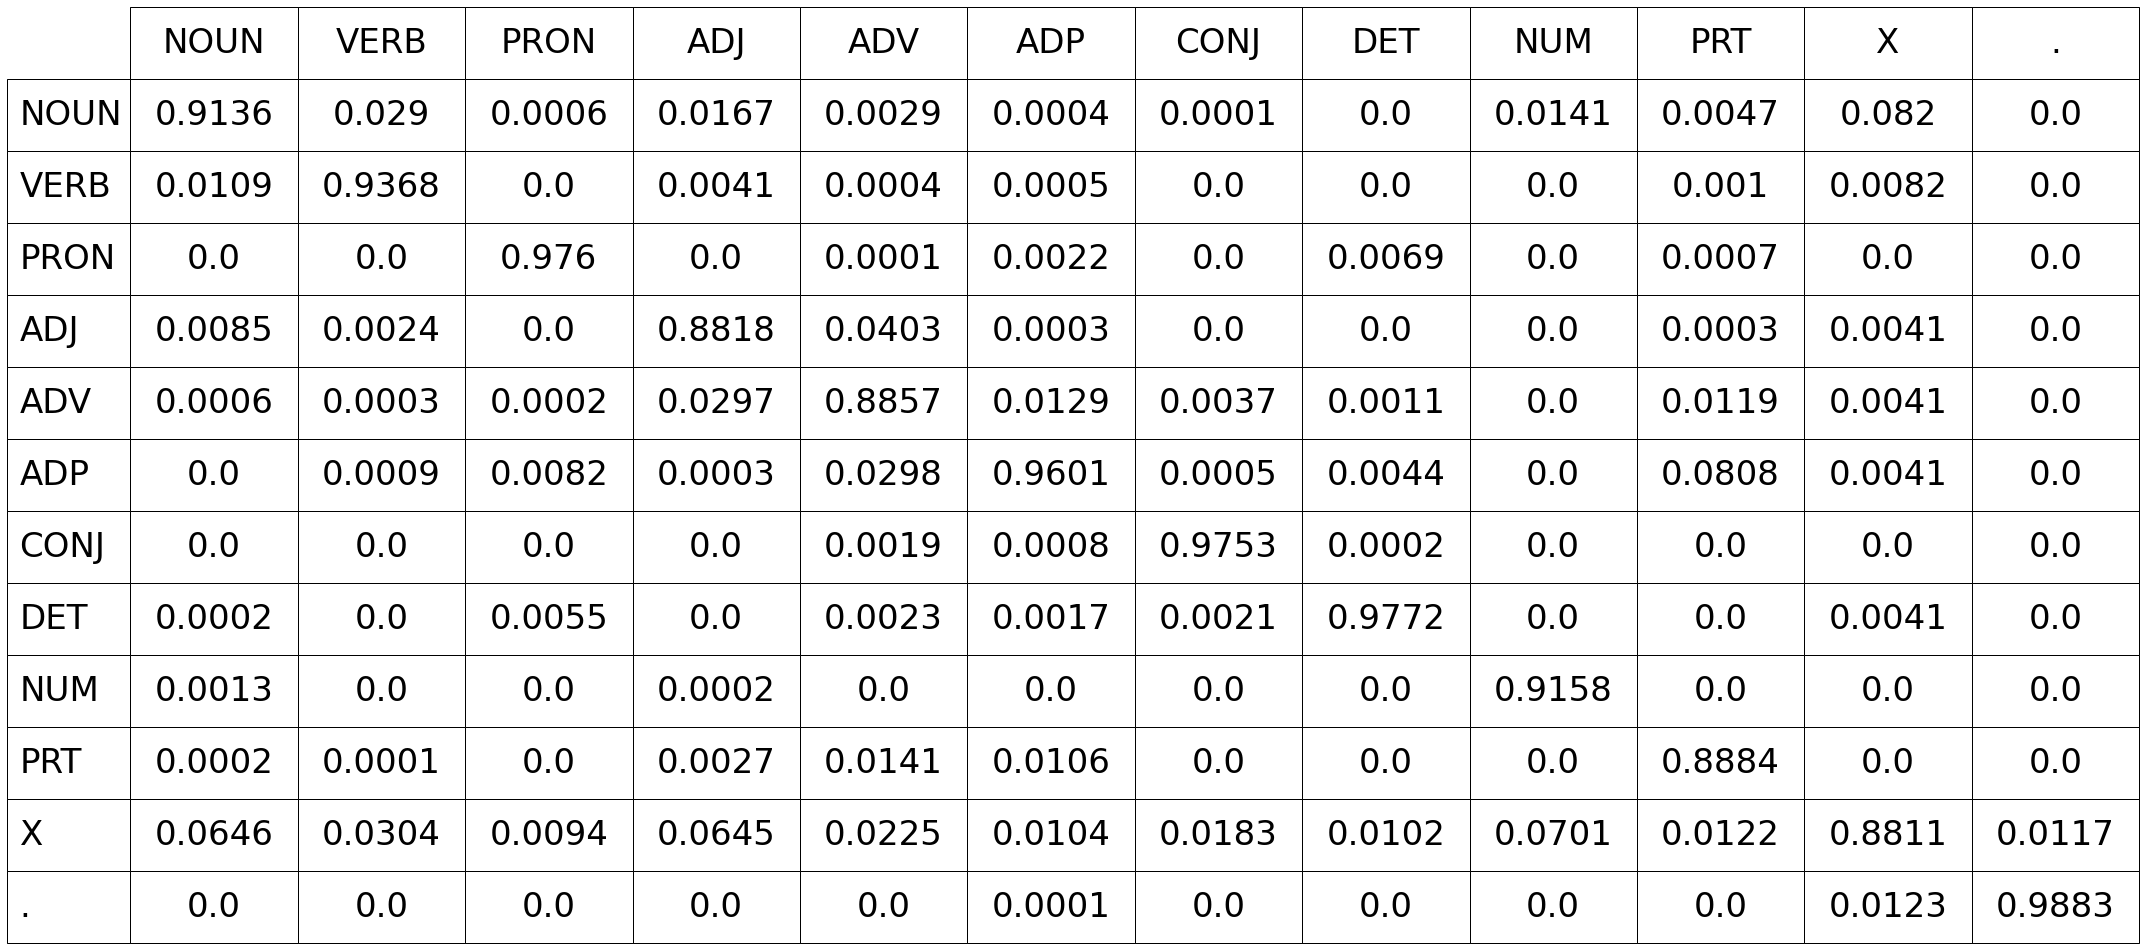

In [64]:
pl.figure()
tb = pl.table(cellText=data_confusion.T, loc=(0,0), cellLoc='center', colLabels = tags, rowLabels = tags)

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)


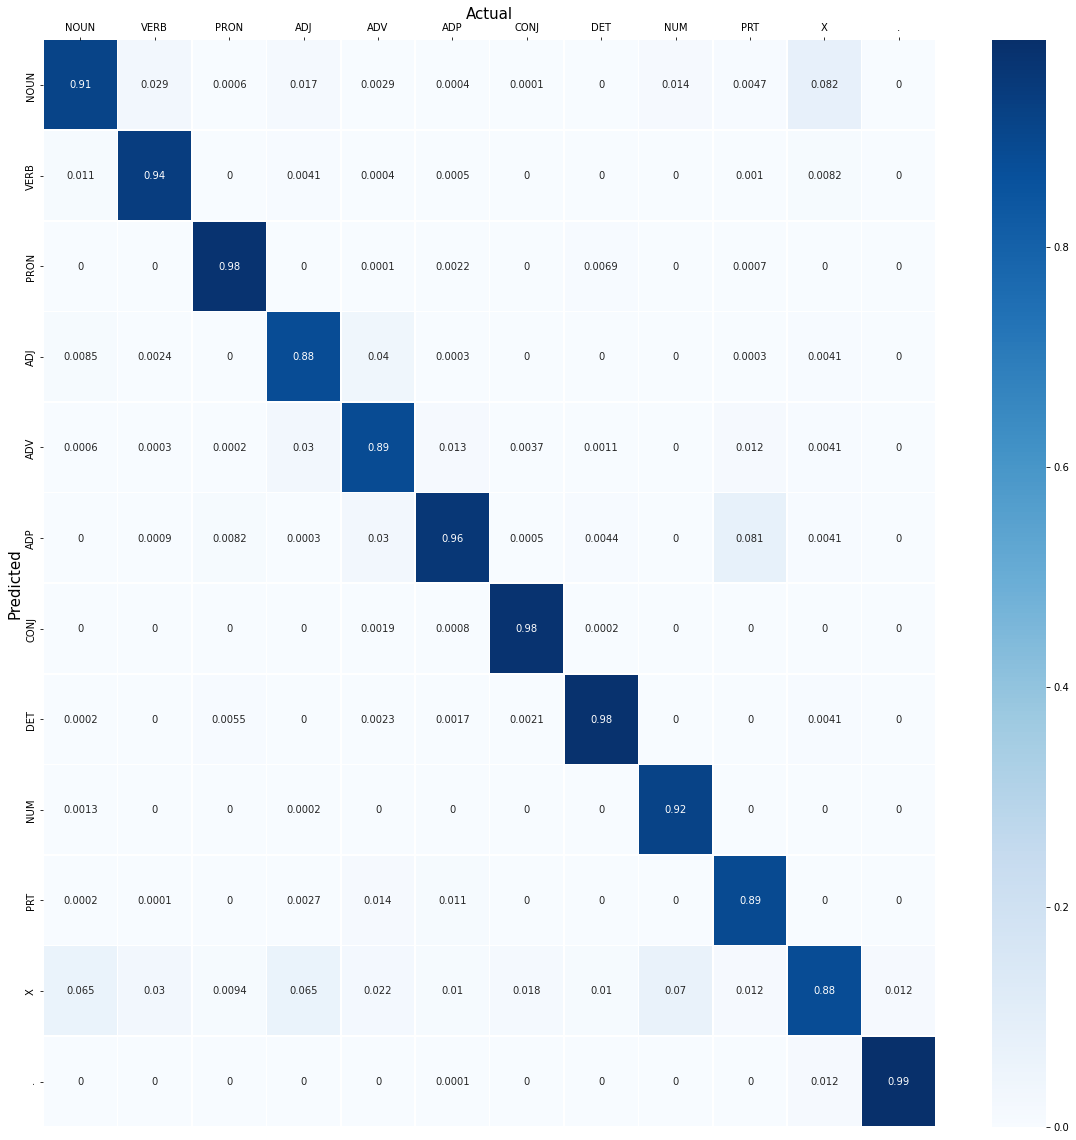

In [65]:

pl.figure(figsize = (20,20))
ax = sns.heatmap(data_confusion.T, annot=True, cmap='Blues', linewidth = 0.5, xticklabels = tags, yticklabels = tags)
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Predicted', fontsize=15)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
pl.show()